In [6]:
from transformers import GPT2LMHeadModel

In [7]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2") # 124M
sd_hf = model_hf.state_dict()

for k, v in sd_hf.items():
    print(k, v.shape)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 8861.12it/s]


transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

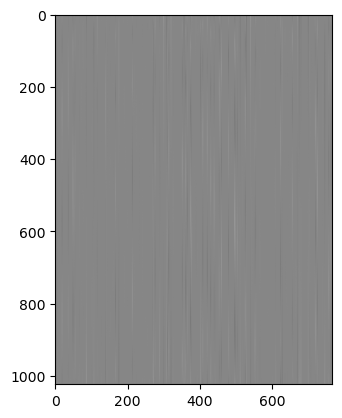

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(sd_hf["transformer.wpe.weight"], cmap="gray")

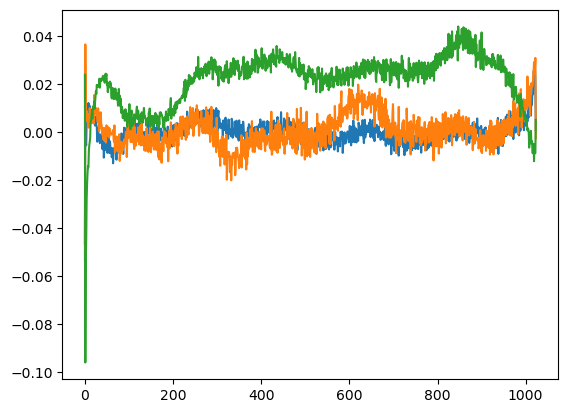

In [9]:
plt.plot(sd_hf["transformer.wpe.weight"][:, 150])
plt.plot(sd_hf["transformer.wpe.weight"][:, 200])
plt.plot(sd_hf["transformer.wpe.weight"][:, 250])

The above is displaying how 3 selected channels behave across the 1000 embedded positions. The curves look jagged because the model is not fully trained and thus doesn't converge to smoother curves.

Original GPT uses fixed positional embeddings that are constructed from sinusoidal waves of different freqs, i.e. Fourier Combo.

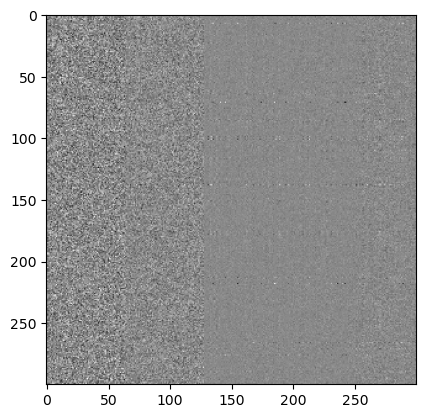

In [10]:
plt.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300,:300], cmap="gray")

In [11]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("Hello, I'm a language model,", max_length=30, num_return_sequences=5)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 16942.52it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_outp

[{'generated_text': "Hello, I'm a language model, and my project is based on the idea of a language model.\n\nI want to have a language that's both expressive and readable.\n\nLet's look at the following code:\n\nimport Data.ByteString\n\ndef get ( self ):\n\nself .data = Data.ByteString(data.get())\n\nself .data.append(data.get())\n\nself .data.append(data.get())\n\nself .data.append(data.get())\n\nself .data.append(data.get())\n\nself .data.append(data.get())\n\nself .data.append(data.get())\n\nself .data.append(data.get())\n\nself .data.append(data.get())\n\nself .data.append(data.get())\n\nself .data.append(data.get())\n\nself .data.append(data.get())\n\nself .data.append(data.get())\n\nself .data.append(data.get())\n\nself .data.append(data.get())\n\nself .data.append(data.get())\n\nself .data.append(data"},
 {'generated_text': "Hello, I'm a language model, not a language model, and if I don't understand it, I won't learn to write it. So I was writing a system for programming in J

In [1]:
with open('input.txt','r') as f:
    text = f.read()
data = text[:1000] #roughly 300+tokens
print(data[:100])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [2]:
import tiktoken
enc = tiktoken.get_encoding('gpt2') #get tokenizer
tokens = enc.encode(data)
tokens[:100]

[5962,
 22307,
 25,
 198,
 8421,
 356,
 5120,
 597,
 2252,
 11,
 3285,
 502,
 2740,
 13,
 198,
 198,
 3237,
 25,
 198,
 5248,
 461,
 11,
 2740,
 13,
 198,
 198,
 5962,
 22307,
 25,
 198,
 1639,
 389,
 477,
 12939,
 2138,
 284,
 4656,
 621,
 284,
 1145,
 680,
 30,
 198,
 198,
 3237,
 25,
 198,
 4965,
 5634,
 13,
 12939,
 13,
 198,
 198,
 5962,
 22307,
 25,
 198,
 5962,
 11,
 345,
 760,
 327,
 1872,
 385,
 1526,
 28599,
 318,
 4039,
 4472,
 284,
 262,
 661,
 13,
 198,
 198,
 3237,
 25,
 198,
 1135,
 760,
 470,
 11,
 356,
 760,
 470,
 13,
 198,
 198,
 5962,
 22307,
 25,
 198,
 5756,
 514,
 1494,
 683,
 11,
 290,
 356]

Notice that the loss at the initial random stage needs to be evaluated, so that the training has a good starting point (not confidently wrong).

IF using cross_entropy, try **-ln(1/vocab_size)** to get standard random generation loss.

## Special: GPU Knowledge

- datasheet in the folder illustrate related data about NVIDIA A100

**Core statement: deep learning doesn't need a high precision. The default FP32 is already too high for deep learning. Here, we prefer FP16; INT8, as a special type, is not used in training (because Gaussian distribution control requires float), but often in inference.**

**Using a layer precision does not only save memory, but also allows more data to be communicated within a fixed bandwidth; in fact, bandwidth is the bottleneck of GPU computations in most cases, and memories are often jsut waiting in idle.**

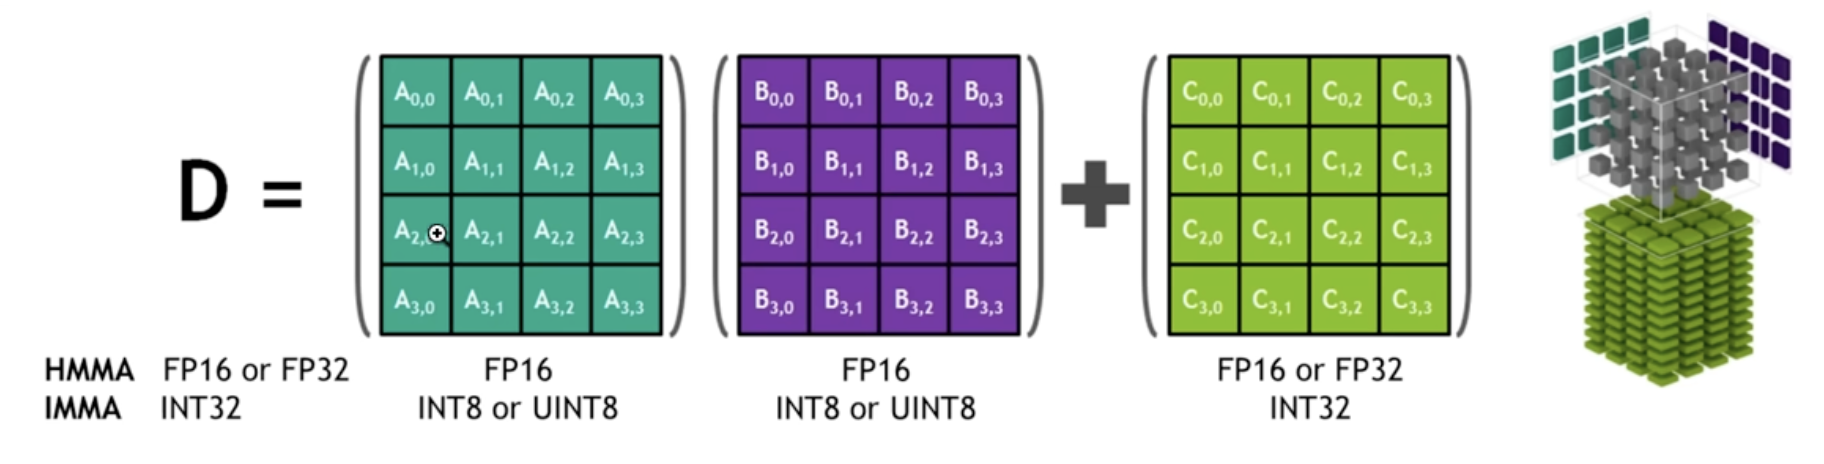

### The pic above shows the internal atom unit of tensor core

**process: split -> multiplication -> accumulation**

### **Contents below illustrates the advantage and mechanism of TF32 (tensor float 32)**

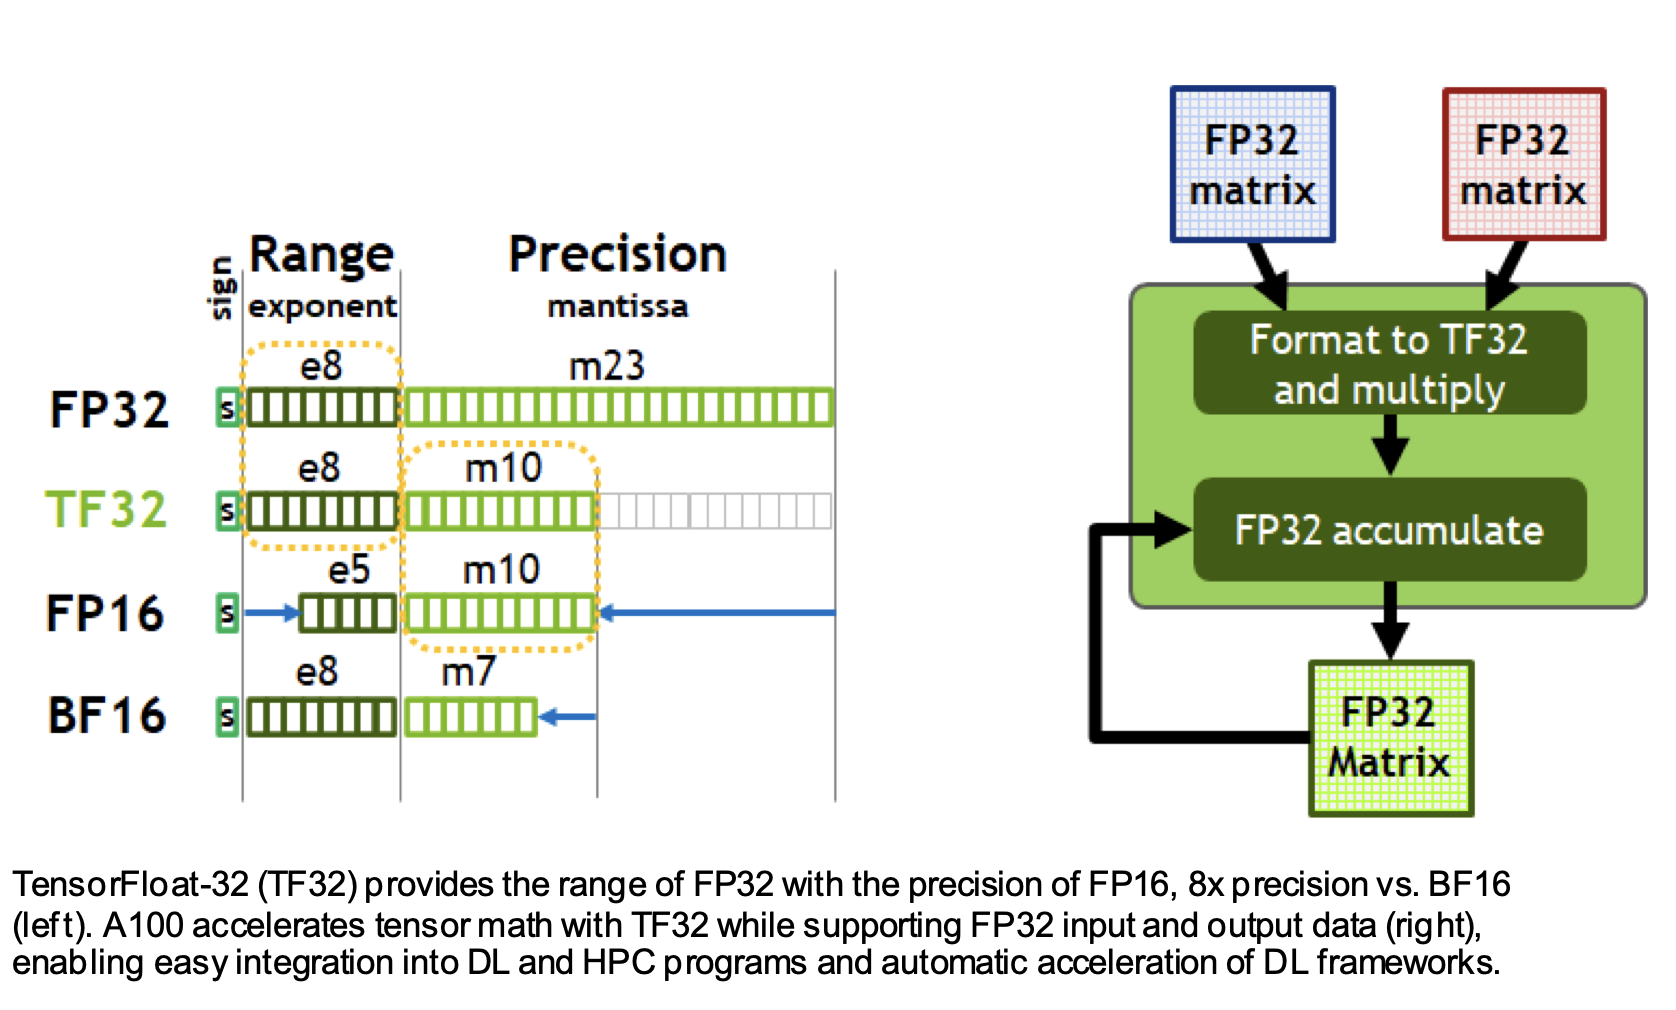

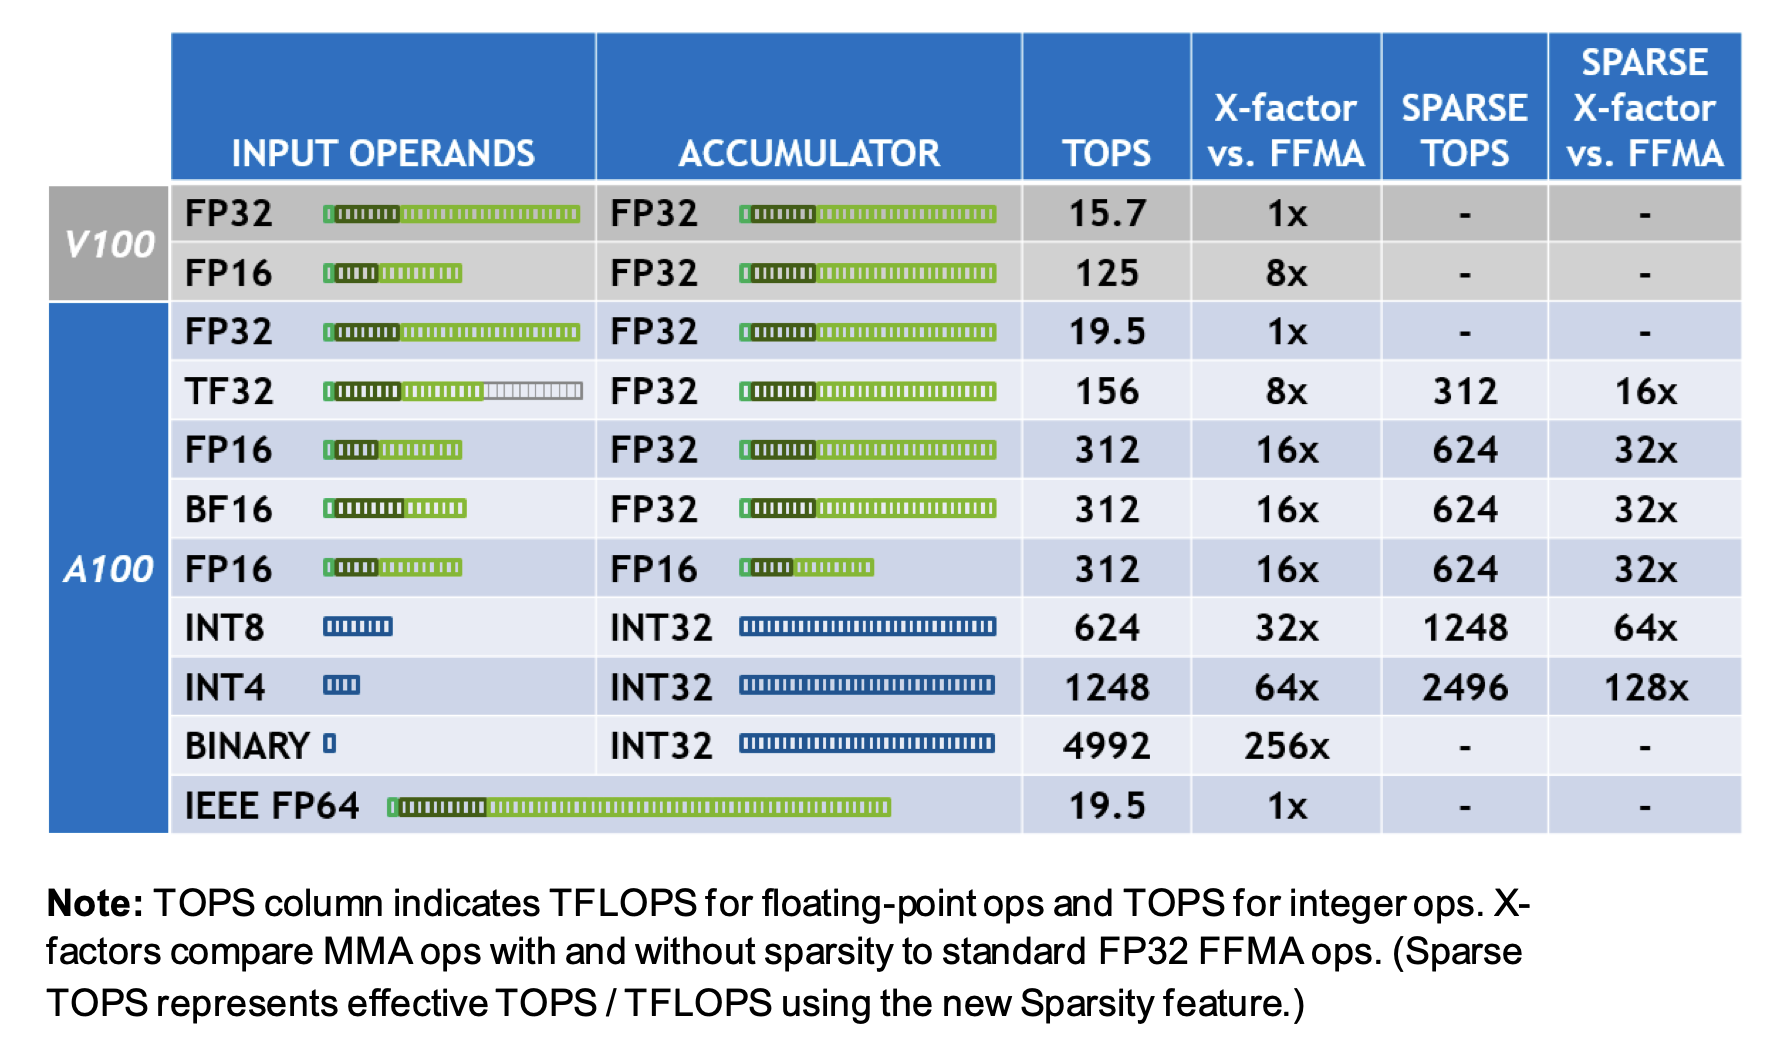

- We can see that, with '32' in name, TF32 actually achieves the same range as FP32, but has sacrificed some precision (10 bits of mantissa) for efficient computation. The most expensive, O(n^3) multiplication part was taken charge of by TF32, while the accumulation (where addition dominates) is done by FP32 to maintain some precision. 
- By using TF32, we achieved a 8x acceleration compared to a FP32 matmul baseline.


- **Since it's hardware-level abstraction, we don't need to adapt our code to it.**

## **BF16**

- Refer to the bit table above, and we can observe that bf16 is actually an upgraded version from the FP16;


- FP16 is in the early Volta series, with a decrease in the exponent bits. Therefore, its range is smaller than FP32, and would require a **gradient scaler** to solve the problem.


- BF16, on the other hand, maintains the same range and just brutally chunked off more mantissa.

- **<span style="color:orange">To use BF16, we use torch.autocast(), which does not convert everything in the model to BF16; components with distributions/special precision susceptibility, e.g., 'norms'/'loss'/'embeddings' are often kept in high precision, while linear layers matmul are significantly accelerated with BF16.</span>**


### **torch.compile()**

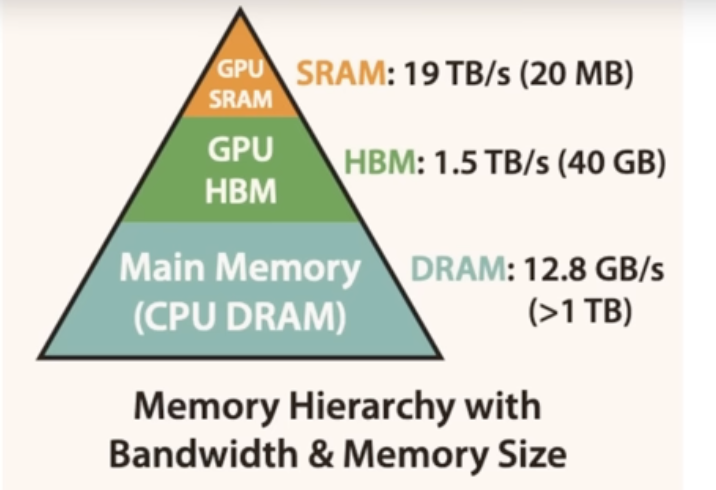

- GPU SRAM is the fastest (on chip), but the total mem amount is very limited (often in MBs).

- The Main Memory is the slowest, we have to ship it from the CPU side DRAM

- GPU HBM (high bandwidth mem, a.k.a, the global mem for GPU) is in the middle. **<span style="color:orange">It helps save the temporary computation results from GPU</span>>**

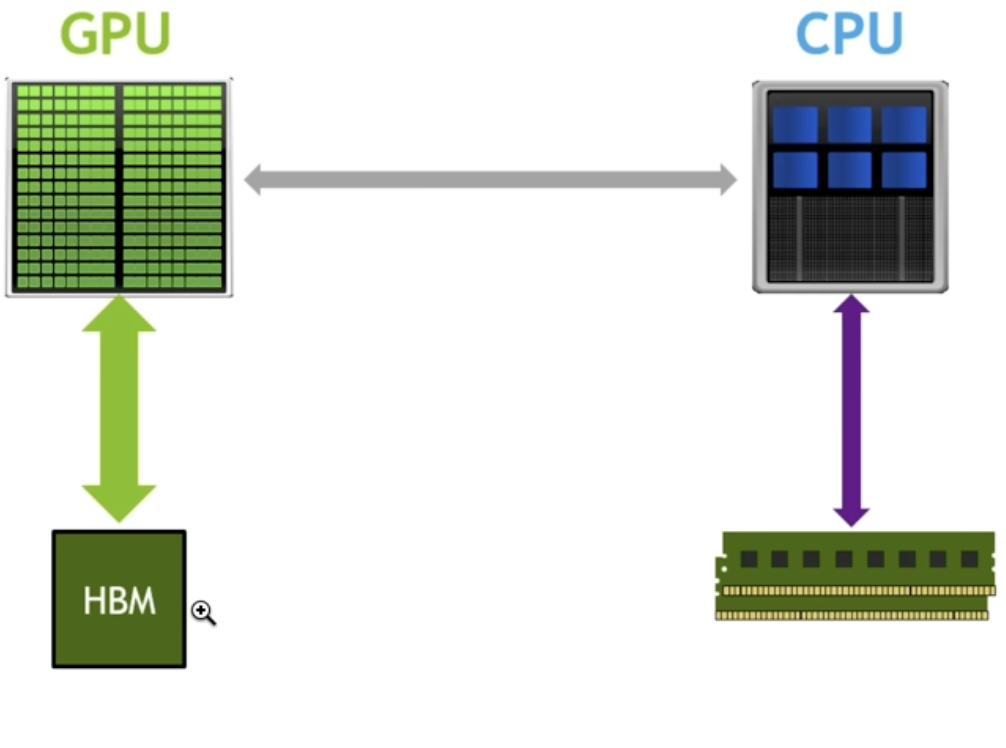

- The core of torch.compile() lies in the memory distributions of GPU. The on-chip mem, a.k.a. the GPU SRAM, has the highest transimision efficiency.

- Torch.compile() allows a **wholistic** compiling procedure that differs from the Python interpreter. It's global view allows it to foresee the computations ahead instead of following a strict sequencial order.

Combining those 2 facts, torch.compile() allows computations to happen with the on-chip mem, **<span style="color:orange">and avoids the round trip that goes back and forth between the chip and the High Bandwidth Memory. A single back and forth trip is enough</span>**

### **<span style="color:red"> This optimization is called Kernel Fusion </span>**

## **Flash Attention**

- Algorithm regarding processing Softmax() in an online manner in single kernels came out early by nvidia. Later the Stanford paper raise this method to a **few-HBM-access attention calculation strategy**:

https://arxiv.org/pdf/2205.14135

- Note that torch.compile() is unable to do this because this is a algorithm-level change.

- **An important lesson to take is that: <span style="color:orange">Flash Attention actually needs more FLOPS, but because of the highly-effcient computation pattern (few mem access), it's able to do the attention significantly faster.</span>**

## **Nice Numbers**

- **CUDA prefers numbers with many factors/powers of 2, because its architecture is in block tiles of nice shape; if the number is not nice, it would spend some time to handle the ugly number distribution.**

- By making the vocab size 50257->50304, we **<span style="color:orange">increased the calculation amount but made the number nicer, and we get from 90ms->88ms roughly. The extra tokens are never used and will be learnt to produce -inf logits.</span>**

## **Increasing Batch Size (Not implemented)**

- As GPT-3 paper points out, in the early stage of training, the model mostly learn about simple biases that favors frequently used tokens. 

- The information is mainly about "use this and don't use that", so intrinsically they are highly correlated.

- With this background, we should achieve a roughly similar result with a smaller batch size, since the model is not fully fired at differentiating information yet.

- So we can train with an increasing batch size. Not implemented here as it's not algorithmic.

## **Weight Decay**

- *Check Makemore.ipynb for initial description*

- The 0.1 coeff is pulling all weights closer to 0, which is the direction of absolute flat distribution; this reduces the entropy of the initial weights and allow us **<span style="color:orange">not to be confidently wrong</span>** at the beginning stage.

## **Gradient Accumulation**

- Sometimes one batch is too large to run on available GPUs.

- We thus cut one batch into many, and process them in series, record and accumulate their gradients, and do backward pass after one whole batch is finished.

## **DDP (Specific line number might update)**

- line 377 (loss/=grad_accum_steps) is giving the correct scaling, since loss should be an index normalized by the size of the whole batch (across GPUs). 

- But this alone doesn't ensure that the loss accumulated by the current process is able to represent the global loss; rather, we need **a synchronization across GPUs that reflects the average loss across GPUs**, which corresponds to our original 'loss of a batch' when NOT using DDP. 

- This is also crucial because after line 377 solved the training problem, we need to print the loss the **watch the training** anyway, and line 382-383 produces a **<span style="color:orange">synchronized result for that instead of letting the master process to give the "global" loss for no reason</span>**.

## **A Review of AdamW**

- ### Adam

$$
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t
$$

$$
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2
$$

$$
\hat m_t=\frac{m_t}{1-\beta_1^t},
\qquad
\hat v_t=\frac{v_t}{1-\beta_2^t}
$$

$$
\theta_t
=
\theta_{t-1}
-
\eta_t\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}
$$

- ### Adam with L2 regularization

$$
L_{\mathrm{total}}
=
L+\frac{\lambda}{2}\|\theta\|_2^2
$$

$$
g_t
\leftarrow
\nabla_\theta L+\lambda\theta
$$

$$
\theta_t
=
\theta_{t-1}
-
\eta_t
\frac{
\operatorname{AdamMoment}(\nabla_\theta L+\lambda\theta)
}{
\sqrt{\operatorname{AdamVariance}(\nabla_\theta L+\lambda\theta)}+\epsilon
}
$$

**We can notice that the loss term in L2-regularized Adam has the weight-variance-control term inside it; therefore, <span style='color:orange'> the regularization is also controlled by the momentum-restriction </span>. This is not good, as we want the regularization to be global, but the momentum-control mechanism is highly specific to individual param's optimization history.**

- ### AdamW: Decoupled Weight Decay

$$
\theta_t
=
(1-\eta_t\lambda)\theta_{t-1}
-
\eta_t\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}
$$

Equivalently:

$$
\theta_t
=
\theta_{t-1}
-
\eta_t
\left(
\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}
+
\lambda\theta_{t-1}
\right)
$$

**Consequently, AdamW <span style="color:orange">decouples the regularization from the momentum control, and makes it an individual update term in charge of weight decay (same essence as the L2 regularization punishment).</span> Carefully select the weight decay coeff $\lambda$, so that the parameter doesn't collapse to 0.** 